In [13]:
!pip install langchain


[notice] A new release of pip available: 22.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import getpass
import os

if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your Groq API key: ")

from langchain_groq import ChatGroq

llm = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
    # other params...
)

In [ ]:
#dynamic query example
messages = [
    (
        "system",
        "You are a helpful assistant that translates English to Bhojpuri. Translate the user sentence.",
    ),
    ("human", "I love programming."),
]
ai_msg = llm.invoke("what is neural network? ")
print(f"response: {ai_msg.content}")



response: A **neural network** is a computational model inspired by the structure and function of the human brain. It is a fundamental component of machine learning and artificial intelligence, designed to recognize patterns, make decisions, and solve complex problems by learning from data. Here's a structured breakdown of its key aspects:

---

### **Core Components**
1. **Neurons (Nodes):**
   - **Artificial Neurons** mimic biological neurons. Each neuron receives inputs, processes them, and produces an output.
   - **Inputs** are multiplied by **weights** (learnable parameters) to determine their influence.
   - A **bias** term is added to adjust the output independently of the inputs.
   - The weighted sum is passed through an **activation function** to introduce non-linearity (e.g., ReLU, sigmoid, tanh).

2. **Layers:**
   - **Input Layer:** Receives raw data (e.g., pixel values of an image).
   - **Hidden Layers:** Intermediate layers that transform inputs into increasingly abstr

In [ ]:
from langchain_core.prompts import ChatPromptTemplate


travel_template="Suggest me  name of a famouse place in one word only to travel on a {location}."

prompt_template = ChatPromptTemplate.from_messages([("system",travel_template),("user","{location}")])



In [ ]:
prompt=prompt_template.invoke({"location":"Patna"})
llm.invoke(prompt)

AIMessage(content='**Golghar**', additional_kwargs={'reasoning_content': "Okay, the user is asking for a famous place in Patna that can be named in one word. Let me think about the key attractions there.\n\nPatna is a historical city in Bihar, India. Some notable places include the Patna Museum, which is a major attraction. Then there's the Golghar, an iconic structure. The Bodh Gaya is nearby, but it's a different city. The Mahabodhi Temple is in Bodh Gaya, so maybe not. The user specifically mentioned Patna, so I should focus on that.\n\nOther options could be the Takht Sri Patna Sahib, which is a significant religious site for Sikhs. Then there's the Agam Kuan, an ancient well. The Vishnupad Ghat is another historical site. The Kumari Maa Temple is also popular. \n\nWait, the user wants a one-word name. Let me check each of these. Patna Museum is two words. Golghar is one word. Takht Sri Patna Sahib is longer. Agam Kuan is two words. Vishnupad Ghat is two words. Kumari Maa Temple is

In [ ]:
prompt_template=ChatPromptTemplate.from_template("Suggest me  name of a famouse place in one word only to travel on a {country} in the month of {month}.")
prompt=prompt_template.invoke({"country":"India","month":"January"})

print(prompt)

response=llm.invoke(prompt)
response.content



messages=[HumanMessage(content='Suggest me  name of a famouse place in one word only to travel on a India in the month of January.', additional_kwargs={}, response_metadata={})]


'**Jaipur**'

## CHAINING

In [ ]:
from langchain_core.output_parsers import StrOutputParser

travel_destination_chain = prompt_template | llm | StrOutputParser()

# travel_destination_chain.invoke({"country": "India", "month": "December"})

travel_itinerary_prompt = ChatPromptTemplate.from_template(
    "Give me 5 days itinerary for the place {destination}"
)

composed_chain = {"destination": travel_destination_chain} | travel_itinerary_prompt | llm | StrOutputParser()
# here the number of times llm is used is 2 times
# first to get the destination and second to get the itinerary then the final output is parsed using StrOutputParser

composed_chain.invoke({"country": "India", "month": "December"})


'Here’s a **5-day itinerary for Goa** that balances beaches, history, culture, and relaxation, with a mix of North and South Goa highlights:\n\n---\n\n### **Day 1: Arrival & Explore Panaji & Anjuna**\n- **Morning**:  \n  - Arrive in Goa and check into a hotel in Panaji (North Goa).  \n  - Visit **Panaji’s Reis Magos Church** and **Panaji Market** for a taste of Portuguese architecture and local spices.  \n- **Afternoon**:  \n  - Head to **Anjuna Beach** for a relaxed lunch at a seaside shacks.  \n  - Explore the **Anjuna Market** (open weekends) for handicrafts, souvenirs, and street food.  \n- **Evening**:  \n  - Sunset at **Arpora Beach** (near Panaji).  \n  - Dinner at a local Goan restaurant (try *Goan fish curry* and *bebinca*).  \n\n---\n\n### **Day 2: Forts & Beaches of North Goa**\n- **Morning**:  \n  - Visit **Fort Aguada** (17th-century Portuguese fort) and enjoy panoramic views of the Arabian Sea.  \n  - Explore the **Basilica of Bom Jesus** (UNESCO World Heritage Site) to s

In [ ]:
# Now below is the Problem 
llm.invoke(" whos is pm of india")

AIMessage(content='As of October 2023, the Prime Minister of India is **Narendra Modi**. He has been serving in this role since May 26, 2014, and was re-elected for a third term in the 2024 general elections. A member of the **Bharatiya Janata Party (BJP)**, Modi is known for his leadership in economic reforms, infrastructure development, and initiatives like "Make in India" and "Digital India." \n\nFor the most up-to-date information, always verify with current news sources, as political positions can change.', additional_kwargs={'reasoning_content': "Okay, the user is asking who the Prime Minister of India is. Let me start by recalling the current political situation in India. As of my last update, Narendra Modi has been serving as the Prime Minister. He was first elected in 2014 and then re-elected in 2019. I should check if there have been any recent elections or changes since then.\n\nWait, the next general election in India is scheduled for 2024, so there hasn't been a new electi

#### problem with llm by default doesnt remeber previous chat

In [ ]:

# LLM bydefault does not remember the previous chat
llm.invoke("whats his age")

AIMessage(content="If you're asking about **Goku's age** from the *Dragon Ball* series, as of the latest manga chapters (up to my knowledge cutoff in July 2024), **Goku is 43 years old** in the current timeline of *Dragon Ball Super*. This is based on the timeline established in the manga, though the anime occasionally adjusts ages slightly for storytelling purposes.\n\nIf you meant someone else, feel free to clarify! 😊", additional_kwargs={'reasoning_content': 'Okay, the user is asking "whats his age" but didn\'t specify who "his" refers to. I need to figure out who they\'re talking about. Let me check the conversation history.\n\nLooking back, the previous messages were about a character named Goku from Dragon Ball. The user asked about Goku\'s age in the latest Dragon Ball Super manga chapter. I provided an answer based on the manga\'s timeline. Now, the user is asking "whats his age" again. Since the context is still about Goku, I should assume they\'re asking for his age again. \n

{'x': 5, 'y': 10, 'result': 30}

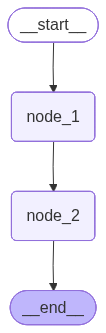

AIMessage(content='LangChain is a framework for building LLM-powered apps with modularity, integrations, and tools for data, agents, and chatbots.', additional_kwargs={'reasoning_content': 'Okay, the user is asking for a 20-word explanation of LangChain. Let me start by recalling what LangChain is. It\'s a framework for building applications with large language models. I need to mention its key features like modularity, integration with various models, and tools for data handling. Also, it\'s used for creating chatbots, agents, and more. Let me check if I can condense that into 20 words without losing the main points. Maybe start with "LangChain is a framework for building LLM-powered apps with modularity, integrations, and tools for data, agents, and chatbots." Let me count the words. That\'s 20. It covers the purpose, key aspects, and examples of applications. I think that works.\n'}, response_metadata={'token_usage': {'completion_tokens': 193, 'prompt_tokens': 18, 'total_tokens': 21

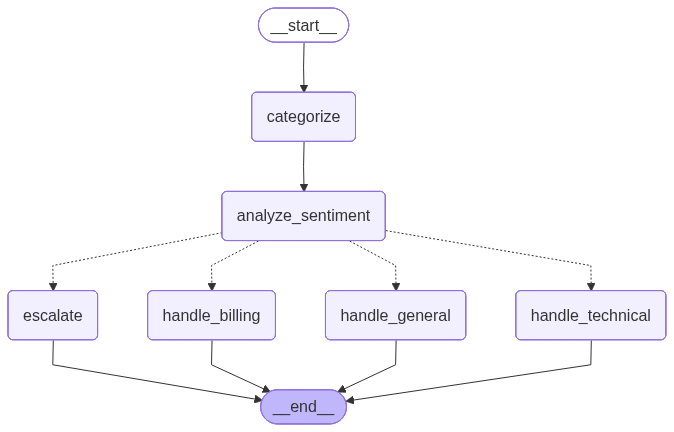


Category : The query "The price value in my invoice is wrong" falls under the **Billing** category. This is because the issue pertains to the accuracy of financial information (price) on an invoice, which is directly related to billing processes. While technical errors could potentially cause such discrepancies, the user's focus is on the billing outcome rather than the underlying technical cause. 

**Category:** Billing

Analyzing the sentiment : 

Sentiment : Negative
Escalating Query


Computed Result
Query: The price value in my invoice is wrong


Category: The query "The price value in my invoice is wrong" falls under the **Billing** category. This is because the issue pertains to the accuracy of financial information (price) on an invoice, which is directly related to billing processes. While technical errors could potentially cause such discrepancies, the user's focus is on the billing outcome rather than the underlying technical cause. 

**Category:** Billing


Sentiment: Nega


Category : The query "my iPhone isn't working" falls under the **Technical** category. This is because it relates to a potential malfunction or issue with the device's functionality, which could involve hardware, software, or system-related problems.

Analyzing the sentiment : 

Sentiment : Negative
Escalating Query


Computed Result
Query: my iphone isnt working


Category: The query "my iPhone isn't working" falls under the **Technical** category. This is because it relates to a potential malfunction or issue with the device's functionality, which could involve hardware, software, or system-related problems.


Sentiment: Negative


Response: This query has been escalate to a human agent due to its negative sentiment





Category : The query is categorized as **Technical**. 

**Reasoning**: The user is reporting a hardware issue (broken screen) with the iPhone 16, which falls under technical problems related to the product's functionality or quality. While dissatisfaction with service expectations could hint at a "General" category, the core issue described is a technical defect in the device itself.

Analyzing the sentiment : 

Sentiment : Negative
Escalating Query


Computed Result
Query: I purchased the iphone 16 but its screen is broken. This is not the kind of service I was expecting


Category: The query is categorized as **Technical**. 

**Reasoning**: The user is reporting a hardware issue (broken screen) with the iPhone 16, which falls under technical problems related to the product's functionality or quality. While dissatisfaction with service expectations could hint at a "General" category, the core issue described is a technical defect in the device itself.


Sentiment: Negative


Response


Category : The query is categorized as **Billing**. The user is requesting an invoice for a new purchase, which directly relates to billing and financial transactions. The mention of being happy with the service is a general comment but does not affect the category.

Analyzing the sentiment : 

Sentiment : Positive

Handling the general query


Computed Result
Query: I am really happy with the service and I want invoice for my new purchase


Category: The query is categorized as **Billing**. The user is requesting an invoice for a new purchase, which directly relates to billing and financial transactions. The mention of being happy with the service is a general comment but does not affect the category.


Sentiment: Positive


Response: Thank you for your kind words and for choosing our service—we’re thrilled to hear you’re happy with your purchase! 🌟  

To assist you with your invoice, could you please provide the **order number** or **purchase date** associated with your transaction?


Category : The query "When is the new iPhone will launching?" is categorized as **General**. 

**Reasoning**: The question pertains to the availability and announcement timeline of a product (iPhone), which falls under general inquiry rather than technical specifications or billing-related concerns.

Analyzing the sentiment : 

Sentiment : Positive

Handling the general query


Computed Result
Query: When is the new iphone will launching?


Category: The query "When is the new iPhone will launching?" is categorized as **General**. 

**Reasoning**: The question pertains to the availability and announcement timeline of a product (iPhone), which falls under general inquiry rather than technical specifications or billing-related concerns.


Sentiment: Positive


Response: Apple typically launches its new iPhone models in **September** each year, with the exact date often falling between the **7th and 15th**. For example, the iPhone 15 series was officially announced on **September 12, 202

## ChatBot